In [7]:
import torch
import pandas as pd
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

nodes_df = pd.read_csv("./pre_processing_output/classification_three_labels_nodes.csv")  # Dataset con nodi (proteine)
edges_df = pd.read_csv("./pre_processing_output/edges.csv")  # Dataset con interazioni proteina-proteina

nodes_df['GO_embeddings'] = nodes_df['GO_embeddings'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
print(nodes_df['label'])
nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(x, dtype=torch.long))

G = nx.Graph()
for _, row in nodes_df.iterrows():
    G.add_node(row['num_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.long))

edges = torch.tensor(edges_df[['num_id_1', 'num_id_2']].values.T, dtype=torch.long)

data = Data(
    x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
    edge_index=edges,  # Edge list
    y=torch.stack([G.nodes[n]['y'] for n in G.nodes])  # Multilabel target
)

print(data)


0      0
1      0
2      0
3      0
4      0
      ..
174    1
175    1
176    1
177    1
178    1
Name: label, Length: 179, dtype: int64
Data(x=[179, 200], edge_index=[2, 666], y=[179])


/tmp/ipykernel_15592/3439168887.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(row['num_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.long))


In [8]:
# Definizione del modello

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

import matplotlib.pyplot as plt

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=3, dropout=0):
        super(GCN, self).__init__()
        
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)  # Output di 3 classi

        self.dropout = dropout
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        """
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        """
        x = self.conv2(x, edge_index)
        return x  # Output logits (senza softmax, lo applicheremo nella loss con CrossEntropyLoss
    
    def train_model(self, data, criterion, optimizer, epochs=200):
        self.train()
        loss_values = []

        for epoch in range(epochs):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)  # Forward pass
            loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Loss su nodi di training
            loss.backward()
            optimizer.step()
            
            loss_values.append(loss.item())

            if epoch % 10 == 0:
                print(f'Epoch {epoch}, Loss: {loss.item():.4f}')
        
        # Mostriamo il grafico della loss
        plt.plot(range(epochs), loss_values, label='Training Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training Loss Curve')
        plt.legend()
        plt.show()



Epoch 0, Loss: 2.7140
Epoch 10, Loss: 0.9933
Epoch 20, Loss: 0.7496
Epoch 30, Loss: 0.6213
Epoch 40, Loss: 0.5556
Epoch 50, Loss: 0.5125
Epoch 60, Loss: 0.4793
Epoch 70, Loss: 0.4524
Epoch 80, Loss: 0.4299
Epoch 90, Loss: 0.4093
Epoch 100, Loss: 0.3905
Epoch 110, Loss: 0.3725
Epoch 120, Loss: 0.3564
Epoch 130, Loss: 0.3418
Epoch 140, Loss: 0.3290
Epoch 150, Loss: 0.3165
Epoch 160, Loss: 0.3052
Epoch 170, Loss: 0.2944
Epoch 180, Loss: 0.2840
Epoch 190, Loss: 0.2738
Epoch 200, Loss: 0.2643
Epoch 210, Loss: 0.2558
Epoch 220, Loss: 0.2484
Epoch 230, Loss: 0.2408
Epoch 240, Loss: 0.2346
Epoch 250, Loss: 0.2282
Epoch 260, Loss: 0.2219
Epoch 270, Loss: 0.2169
Epoch 280, Loss: 0.2113
Epoch 290, Loss: 0.2072
Epoch 300, Loss: 0.2016
Epoch 310, Loss: 0.1971
Epoch 320, Loss: 0.1931
Epoch 330, Loss: 0.1904
Epoch 340, Loss: 0.1865
Epoch 350, Loss: 0.1821
Epoch 360, Loss: 0.1821
Epoch 370, Loss: 0.1760
Epoch 380, Loss: 0.1728
Epoch 390, Loss: 0.1701
Epoch 400, Loss: 0.1672
Epoch 410, Loss: 0.1651
Epo

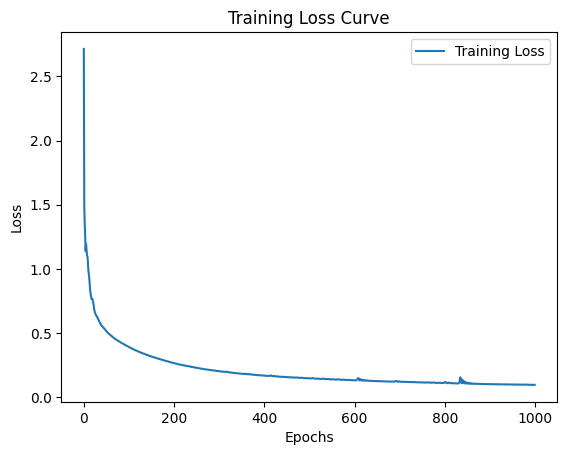

In [9]:
# Train-test split e addestramento
from torch.optim import Adam

num_nodes = data.x.shape[0]
train_mask = torch.rand(num_nodes) < 0.8  # 80% training, 20% test
test_mask = ~train_mask

data.train_mask = train_mask
data.test_mask = test_mask
model = GCN(in_channels=data.x.shape[1], hidden_channels=64, out_channels=3)
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

model.train_model(data, criterion=nn.CrossEntropyLoss(), optimizer=optimizer, epochs=1000)

In [10]:
# Metriche di valutazione

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def test():
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)  # Output logits
        pred = out.argmax(dim=1)  # Prendiamo la classe con probabilità massima

        y_true = data.y[data.test_mask].cpu().numpy()
        y_pred = pred[data.test_mask].cpu().numpy()

        precision = precision_score(y_true, y_pred, average="macro")
        recall = recall_score(y_true, y_pred, average="macro")
        f1 = f1_score(y_true, y_pred, average="macro")

        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-score: {f1:.4f}")

        # Matrice di confusione
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6,6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

Precision: 0.2699
Recall: 0.2798
F1-score: 0.2618


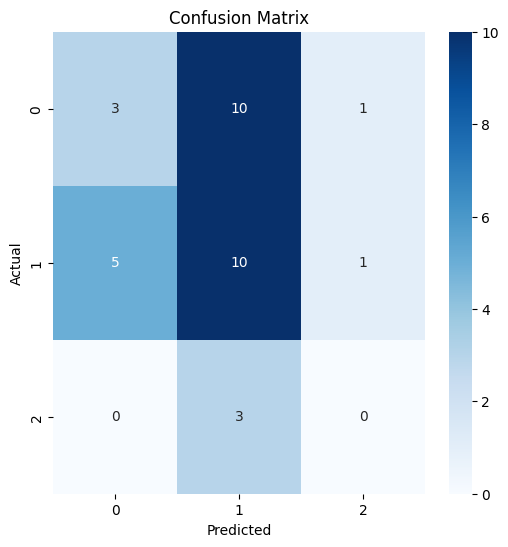

In [11]:
with torch.no_grad():
    out_test = model(data.x, data.edge_index)  # Predizioni della GCN
    y_pred = out_test[test_mask].numpy()  # Convertiamo in array numpy
    y_true = data.y[test_mask].numpy()  # Ground truth

test()